In [1]:
# All libraries we need for this phase
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import os
from collections import Counter

# Makes plots appear inside the notebook
%matplotlib inline

# Makes plots look clean and professional
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print(" Libraries loaded!")

 Libraries loaded!


In [2]:
# Load the ground truth labels
labels_df = pd.read_csv("data/raw/anomaly_label.csv")

# Strip any accidental spaces from column names
labels_df.columns = labels_df.columns.str.strip()

# Strip spaces from values too
labels_df['Label'] = labels_df['Label'].str.strip()

print(" Labels loaded!")
print(f"Shape: {labels_df.shape}")
print(labels_df.head())

 Labels loaded!
Shape: (575061, 2)
                    BlockId    Label
0  blk_-1608999687919862906   Normal
1   blk_7503483334202473044   Normal
2  blk_-3544583377289625738  Anomaly
3  blk_-9073992586687739851   Normal
4   blk_7854771516489510256   Normal


In [3]:
# We'll load the log file line by line into a list
log_lines = []

with open("data/raw/HDFS.log", "r") as f:
    for line in f:
        log_lines.append(line.strip())

print(f" Total log lines loaded: {len(log_lines):,}")
print(f"\nSample lines:")
print("-" * 80)
for line in log_lines[:5]:
    print(line)

 Total log lines loaded: 11,175,629

Sample lines:
--------------------------------------------------------------------------------
081109 203518 143 INFO dfs.DataNode$DataXceiver: Receiving block blk_-1608999687919862906 src: /10.250.19.102:54106 dest: /10.250.19.102:50010
081109 203518 35 INFO dfs.FSNamesystem: BLOCK* NameSystem.allocateBlock: /mnt/hadoop/mapred/system/job_200811092030_0001/job.jar. blk_-1608999687919862906
081109 203519 143 INFO dfs.DataNode$DataXceiver: Receiving block blk_-1608999687919862906 src: /10.250.10.6:40524 dest: /10.250.10.6:50010
081109 203519 145 INFO dfs.DataNode$DataXceiver: Receiving block blk_-1608999687919862906 src: /10.250.14.224:42420 dest: /10.250.14.224:50010
081109 203519 145 INFO dfs.DataNode$PacketResponder: PacketResponder 1 for block blk_-1608999687919862906 terminating


In [4]:
# Look at one log line carefully
sample_line = log_lines[0]
print("ONE LOG LINE:")
print(sample_line)
print()

# A typical HDFS log line looks like:
# 081109 203518 143 INFO dfs.DataNode$DataXceiver: Receiving block blk_XXX ...
# Let's break it into parts manually

parts = sample_line.split()
print("Breaking it into parts:")
print(f"  Date       : {parts[0]}")
print(f"  Time       : {parts[1]}")
print(f"  Process ID : {parts[2]}")
print(f"  Log Level  : {parts[3]}")
print(f"  Component  : {parts[4]}")
print(f"  Message    : {' '.join(parts[5:])}")

ONE LOG LINE:
081109 203518 143 INFO dfs.DataNode$DataXceiver: Receiving block blk_-1608999687919862906 src: /10.250.19.102:54106 dest: /10.250.19.102:50010

Breaking it into parts:
  Date       : 081109
  Time       : 203518
  Process ID : 143
  Log Level  : INFO
  Component  : dfs.DataNode$DataXceiver:
  Message    : Receiving block blk_-1608999687919862906 src: /10.250.19.102:54106 dest: /10.250.19.102:50010


In [5]:
# This is the core parsing function
# It extracts structured fields from each raw log line using regex

def parse_log_line(line):
    """
    Parses a single HDFS log line into structured fields.
    Returns a dictionary with extracted components.
    """

    # Regex pattern matching the HDFS log format:
    # DATE TIME PID LEVEL COMPONENT: MESSAGE
    pattern = r'(\d{6})\s(\d{6})\s(\d+)\s(\w+)\s([\w\.\$]+):\s(.*)'
    
    match = re.match(pattern, line)
    
    if match:
        return {
            'Date'      : match.group(1),   # e.g. 081109
            'Time'      : match.group(2),   # e.g. 203518
            'Pid'       : int(match.group(3)),  # Process ID
            'Level'     : match.group(4),   # INFO, WARN, ERROR
            'Component' : match.group(5),   # dfs.DataNode etc
            'Content'   : match.group(6)    # The actual message
        }
    else:
        return None  # Line didn't match expected format

# Parse every line (this may take 1-2 minutes for 11M lines)
print(" Parsing log lines... please wait")

parsed = []
failed = 0

for line in log_lines:
    result = parse_log_line(line)
    if result:
        parsed.append(result)
    else:
        failed += 1

# Convert to DataFrame
logs_df = pd.DataFrame(parsed)

print(f" Successfully parsed : {len(logs_df):,} lines")
print(f"  Failed to parse   : {failed:,} lines")
print(f"\nDataFrame shape: {logs_df.shape}")
print(logs_df.head())

 Parsing log lines... please wait
 Successfully parsed : 11,175,629 lines
  Failed to parse   : 0 lines

DataFrame shape: (11175629, 6)
     Date    Time  Pid Level                     Component  \
0  081109  203518  143  INFO      dfs.DataNode$DataXceiver   
1  081109  203518   35  INFO              dfs.FSNamesystem   
2  081109  203519  143  INFO      dfs.DataNode$DataXceiver   
3  081109  203519  145  INFO      dfs.DataNode$DataXceiver   
4  081109  203519  145  INFO  dfs.DataNode$PacketResponder   

                                             Content  
0  Receiving block blk_-1608999687919862906 src: ...  
1  BLOCK* NameSystem.allocateBlock: /mnt/hadoop/m...  
2  Receiving block blk_-1608999687919862906 src: ...  
3  Receiving block blk_-1608999687919862906 src: ...  
4  PacketResponder 1 for block blk_-1608999687919...  


In [7]:
# Block IDs are the KEY that links log lines to anomaly labels
# Every anomaly label is tied to a Block ID like: blk_-1608999687919862906
# We must extract this from the Content column

def extract_block_id(content):
    """
    Extracts block ID from log message content.
    Block IDs follow the pattern: blk_<number>
    """
    match = re.search(r'(blk_-?\d+)', content)
    if match:
        return match.group(1)
    return None   # Some lines don't mention a block

# Apply to every row
logs_df['BlockId'] = logs_df['Content'].apply(extract_block_id)

# How many lines have a Block ID?
has_block = logs_df['BlockId'].notna().sum()
total     = len(logs_df)

print(f" Lines with Block ID    : {has_block:,}  ({100*has_block/total:.1f}%)")
print(f"  Lines without Block ID: {total - has_block:,}")
print()
print(logs_df[['Level', 'Component', 'Content', 'BlockId']].head(10))

 Lines with Block ID    : 11,175,629  (100.0%)
  Lines without Block ID: 0

  Level                     Component  \
0  INFO      dfs.DataNode$DataXceiver   
1  INFO              dfs.FSNamesystem   
2  INFO      dfs.DataNode$DataXceiver   
3  INFO      dfs.DataNode$DataXceiver   
4  INFO  dfs.DataNode$PacketResponder   
5  INFO  dfs.DataNode$PacketResponder   
6  INFO  dfs.DataNode$PacketResponder   
7  INFO  dfs.DataNode$PacketResponder   
8  INFO  dfs.DataNode$PacketResponder   
9  INFO  dfs.DataNode$PacketResponder   

                                             Content                   BlockId  
0  Receiving block blk_-1608999687919862906 src: ...  blk_-1608999687919862906  
1  BLOCK* NameSystem.allocateBlock: /mnt/hadoop/m...  blk_-1608999687919862906  
2  Receiving block blk_-1608999687919862906 src: ...  blk_-1608999687919862906  
3  Receiving block blk_-1608999687919862906 src: ...  blk_-1608999687919862906  
4  PacketResponder 1 for block blk_-1608999687919...  blk_-16089996

In [11]:
# Now we connect each log line to its anomaly label
# using BlockId as the joining key

logs_df = logs_df.merge(
    labels_df,          # The labels dataframe
    on='BlockId',       # Join on the BlockId column
    how='left'          # Keep all log lines, even those without a label
)

# Lines without a Block ID get NaN label — fill with 'Unknown'
logs_df['Label'] = logs_df['Label'].fillna('Unknown')

print(" Labels attached!")
print()
print("Label distribution across ALL log lines:")
print(logs_df['Label'].value_counts())
print()
print(logs_df[['Date', 'Level', 'BlockId', 'Label']].head(10))

 Labels attached!

Label distribution across ALL log lines:
Label
Normal     10887379
Anomaly      288250
Name: count, dtype: int64

     Date Level                   BlockId   Label
0  081109  INFO  blk_-1608999687919862906  Normal
1  081109  INFO  blk_-1608999687919862906  Normal
2  081109  INFO  blk_-1608999687919862906  Normal
3  081109  INFO  blk_-1608999687919862906  Normal
4  081109  INFO  blk_-1608999687919862906  Normal
5  081109  INFO  blk_-1608999687919862906  Normal
6  081109  INFO  blk_-1608999687919862906  Normal
7  081109  INFO  blk_-1608999687919862906  Normal
8  081109  INFO  blk_-1608999687919862906  Normal
9  081109  INFO  blk_-1608999687919862906  Normal


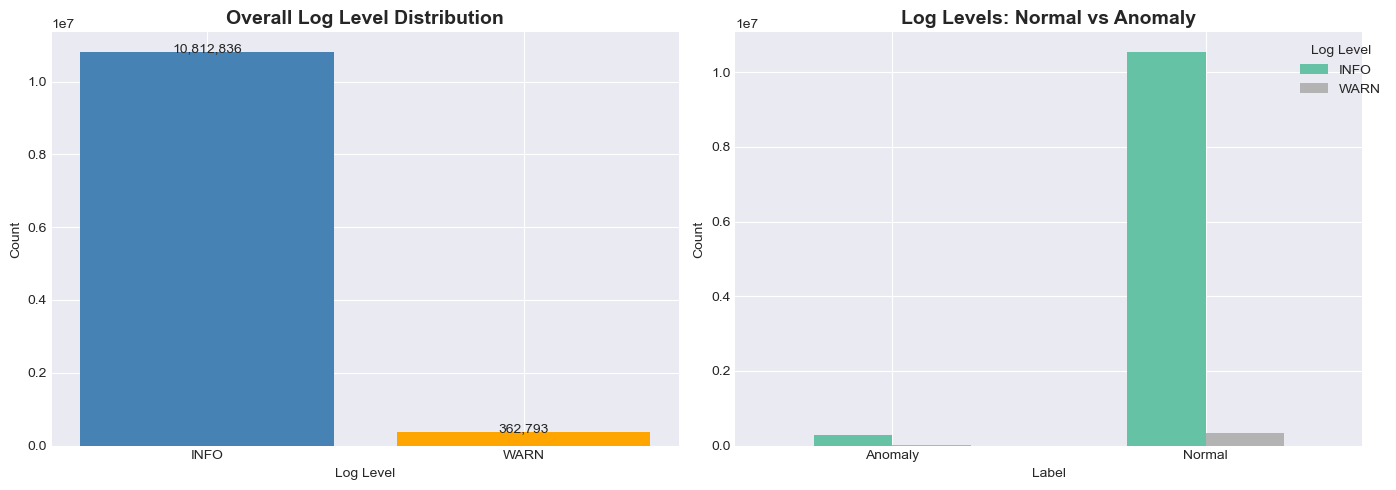

 Plot saved to results/plots/


In [12]:
# Log levels (INFO, WARN, ERROR) are important signals for anomaly detection
# Anomalies often produce more WARN and ERROR entries

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Plot 1: Overall log level distribution ---
level_counts = logs_df['Level'].value_counts()

axes[0].bar(level_counts.index, level_counts.values, 
            color=['steelblue', 'orange', 'red', 'green'])
axes[0].set_title('Overall Log Level Distribution', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Log Level')
axes[0].set_ylabel('Count')
for i, v in enumerate(level_counts.values):
    axes[0].text(i, v + 1000, f'{v:,}', ha='center', fontsize=10)

# --- Plot 2: Log levels split by Normal vs Anomaly ---
labeled = logs_df[logs_df['Label'].isin(['Normal', 'Anomaly'])]
level_label = labeled.groupby(['Label', 'Level']).size().unstack(fill_value=0)
level_label.plot(kind='bar', ax=axes[1], colormap='Set2')
axes[1].set_title('Log Levels: Normal vs Anomaly', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Label')
axes[1].set_ylabel('Count')
axes[1].legend(title='Log Level', bbox_to_anchor=(1.05, 1))
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.savefig("results/plots/log_level_distribution.png", dpi=150, bbox_inches='tight')
plt.show()
print(" Plot saved to results/plots/")

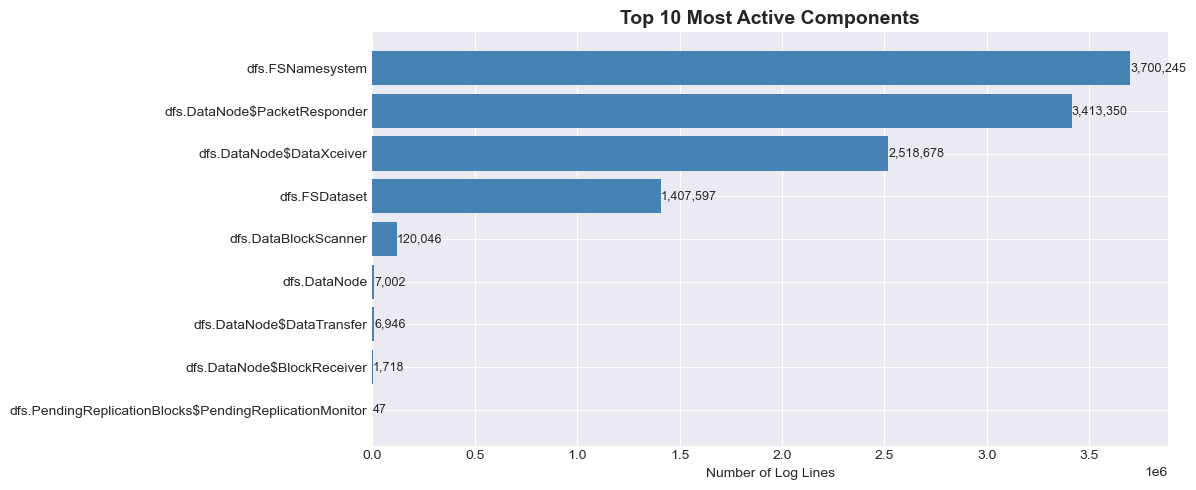

In [13]:
# Which system components generate the most logs?
# And do anomalies cluster around specific components?

top_components = logs_df['Component'].value_counts().head(10)

plt.figure(figsize=(12, 5))
bars = plt.barh(top_components.index[::-1], 
                top_components.values[::-1], 
                color='steelblue')
plt.title('Top 10 Most Active Components', fontsize=14, fontweight='bold')
plt.xlabel('Number of Log Lines')

for bar, val in zip(bars, top_components.values[::-1]):
    plt.text(bar.get_width() + 500, bar.get_y() + bar.get_height()/2,
             f'{val:,}', va='center', fontsize=9)

plt.tight_layout()
plt.savefig("results/plots/component_distribution.png", dpi=150, bbox_inches='tight')
plt.show()

In [15]:
# Save the parsed and labeled DataFrame for use in the next phase
output_path = "data/processed/logs_parsed.csv"
logs_df.to_csv(output_path, index=False)

print(f" Cleaned data saved to: {output_path}")
print(f"   Shape   : {logs_df.shape}")
print(f"   Columns : {list(logs_df.columns)}")
print()
print("=" * 50)
print("   PHASE 2 COMPLETE!")
print("=" * 50)
print()
print("What we did:")
print("   Loaded 11M+ raw log lines")
print("   Parsed into structured fields")
print("   Extracted Block IDs")
print("   Attached anomaly labels")
print("   Explored log levels and components")
print("   Saved clean data to data/processed/")

 Cleaned data saved to: data/processed/logs_parsed.csv
   Shape   : (11175629, 10)
   Columns : ['Date', 'Time', 'Pid', 'Level', 'Component', 'Content', 'BlockId', 'Label_x', 'Label_y', 'Label']

   PHASE 2 COMPLETE!

What we did:
   Loaded 11M+ raw log lines
   Parsed into structured fields
   Extracted Block IDs
   Attached anomaly labels
   Explored log levels and components
   Saved clean data to data/processed/
